# **1. Perkenalan Dataset**


## Deskripsi Dataset

Dataset yang digunakan adalah **Water Quality and Potability** yang tersedia secara publik di [Kaggle](https://www.kaggle.com/datasets/adityakadiwal/water-potability).

### Informasi Dataset
- **Nama**: Water Potability Dataset
- **Sumber**: Kaggle – Aditya Kadiwal
- **Jumlah Baris**: 3.276 sampel
- **Jumlah Kolom**: 10 fitur + 1 target
- **Task**: Binary Classification (Air layak minum atau tidak)

### Fitur Dataset
| Fitur | Deskripsi |
|---|---|
| `ph` | Nilai pH air (0-14) |
| `Hardness` | Kapasitas air untuk mengendapkan sabun (mg/L) |
| `Solids` | Total padatan terlarut (TDS) dalam ppm |
| `Chloramines` | Jumlah Chloramines (ppm) |
| `Sulfate` | Jumlah Sulfate terlarut (mg/L) |
| `Conductivity` | Konduktivitas listrik air (μS/cm) |
| `Organic_carbon` | Jumlah karbon organik dalam ppm |
| `Trihalomethanes` | Jumlah Trihalomethanes dalam μg/L |
| `Turbidity` | Ukuran sifat pemantulan cahaya air (NTU) |
| `Potability` | **Target** – Indikasi kelayakan air (1=layak, 0=tidak layak) |

# **2. Import Library**

Mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


# **3. Memuat Dataset**

Memuat dataset Water Quality dari Kaggle dan memeriksa beberapa baris awal untuk memahami strukturnya.

In [4]:
# Load dataset
df = pd.read_csv('water_potability.csv')

print('=== INFORMASI DATASET ===')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
print('=== 5 BARIS PERTAMA ===')
df.head()

=== INFORMASI DATASET ===
Jumlah baris: 3276
Jumlah kolom: 10

=== 5 BARIS PERTAMA ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
# Melihat informasi tipe data
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().round(3)

=== STATISTIK DESKRIPTIF ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000,3276.000,3276.000,3276.000,2495.000,3276.000,3276.000,3114.000,3276.000,3276.000
mean,7.081,196.369,22014.093,7.122,333.776,426.205,14.285,66.396,3.967,0.390
std,1.594,32.880,8768.571,1.583,41.417,80.824,3.308,16.175,0.780,0.488
min,0.000,47.432,320.943,0.352,129.000,181.484,2.200,0.738,1.450,0.000
25%,6.093,176.851,15666.690,6.127,307.699,365.734,12.066,55.845,3.440,0.000
50%,7.037,196.968,20927.834,7.130,333.074,421.885,14.218,66.622,3.955,0.000
75%,8.062,216.667,27332.762,8.115,359.950,481.792,16.558,77.337,4.500,1.000
max,14.000,323.124,61227.196,13.127,481.031,753.343,28.300,124.000,6.739,1.000


# **4. Exploratory Data Analysis (EDA)**

Melakukan EDA untuk memahami karakteristik dataset Water Quality.

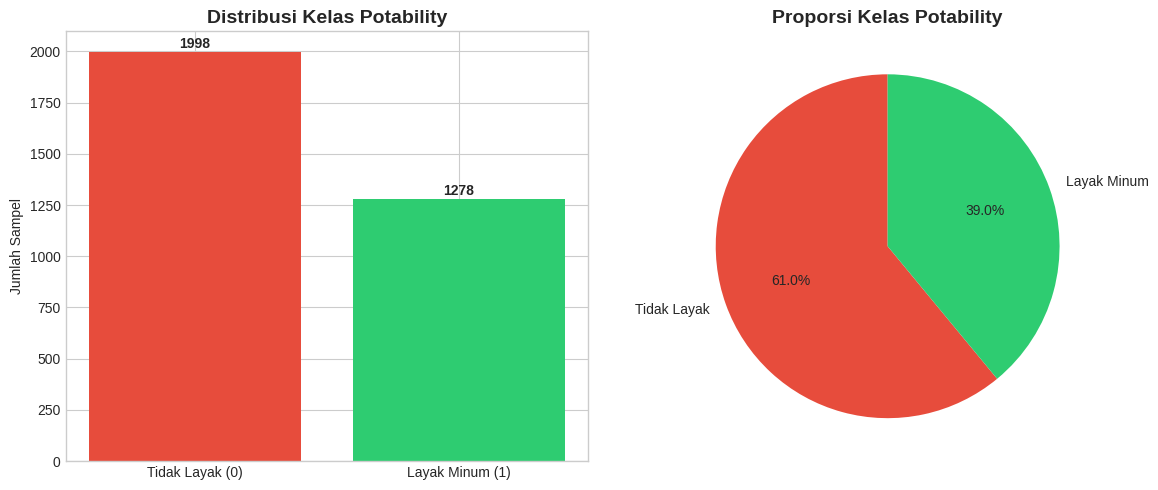


Distribusi kelas:
Potability
0    1998
1    1278
Name: count, dtype: int64

Persentase:
Potability
0    60.99
1    39.01
Name: count, dtype: float64


In [7]:
# 4.1 Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
potability_counts = df['Potability'].value_counts()
axes[0].bar(['Tidak Layak (0)', 'Layak Minum (1)'],
            potability_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Potability', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(potability_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(potability_counts.values,
            labels=['Tidak Layak', 'Layak Minum'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas Potability', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDistribusi kelas:\n{potability_counts}')
print(f'\nPersentase:\n{(potability_counts/len(df)*100).round(2)}')

=== MISSING VALUES ===
                 Missing Count  Missing %
ph                         491      14.99
Sulfate                    781      23.84
Trihalomethanes            162       4.95


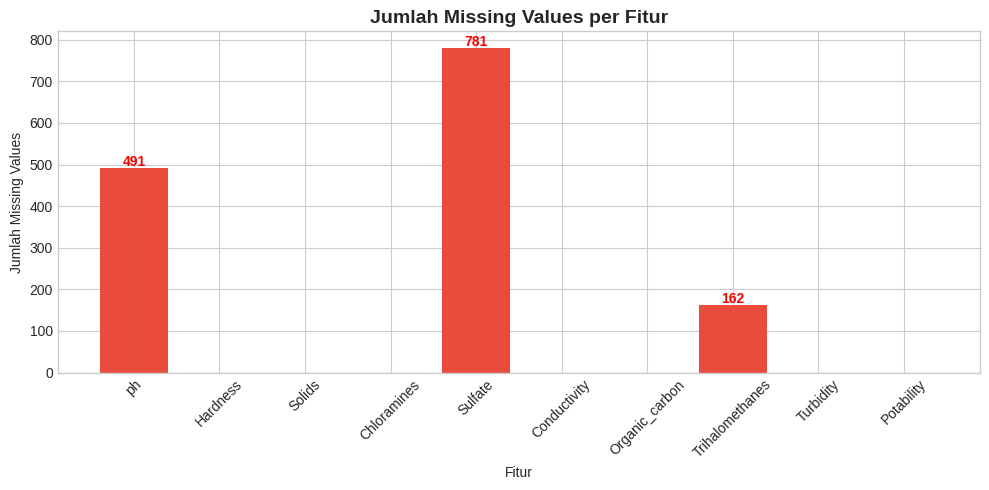

In [8]:
# 4.2 Cek Missing Values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in missing.values]
bars = ax.bar(missing.index, missing.values, color=colors)
ax.set_title('Jumlah Missing Values per Fitur', fontsize=14, fontweight='bold')
ax.set_xlabel('Fitur')
ax.set_ylabel('Jumlah Missing Values')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, missing.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

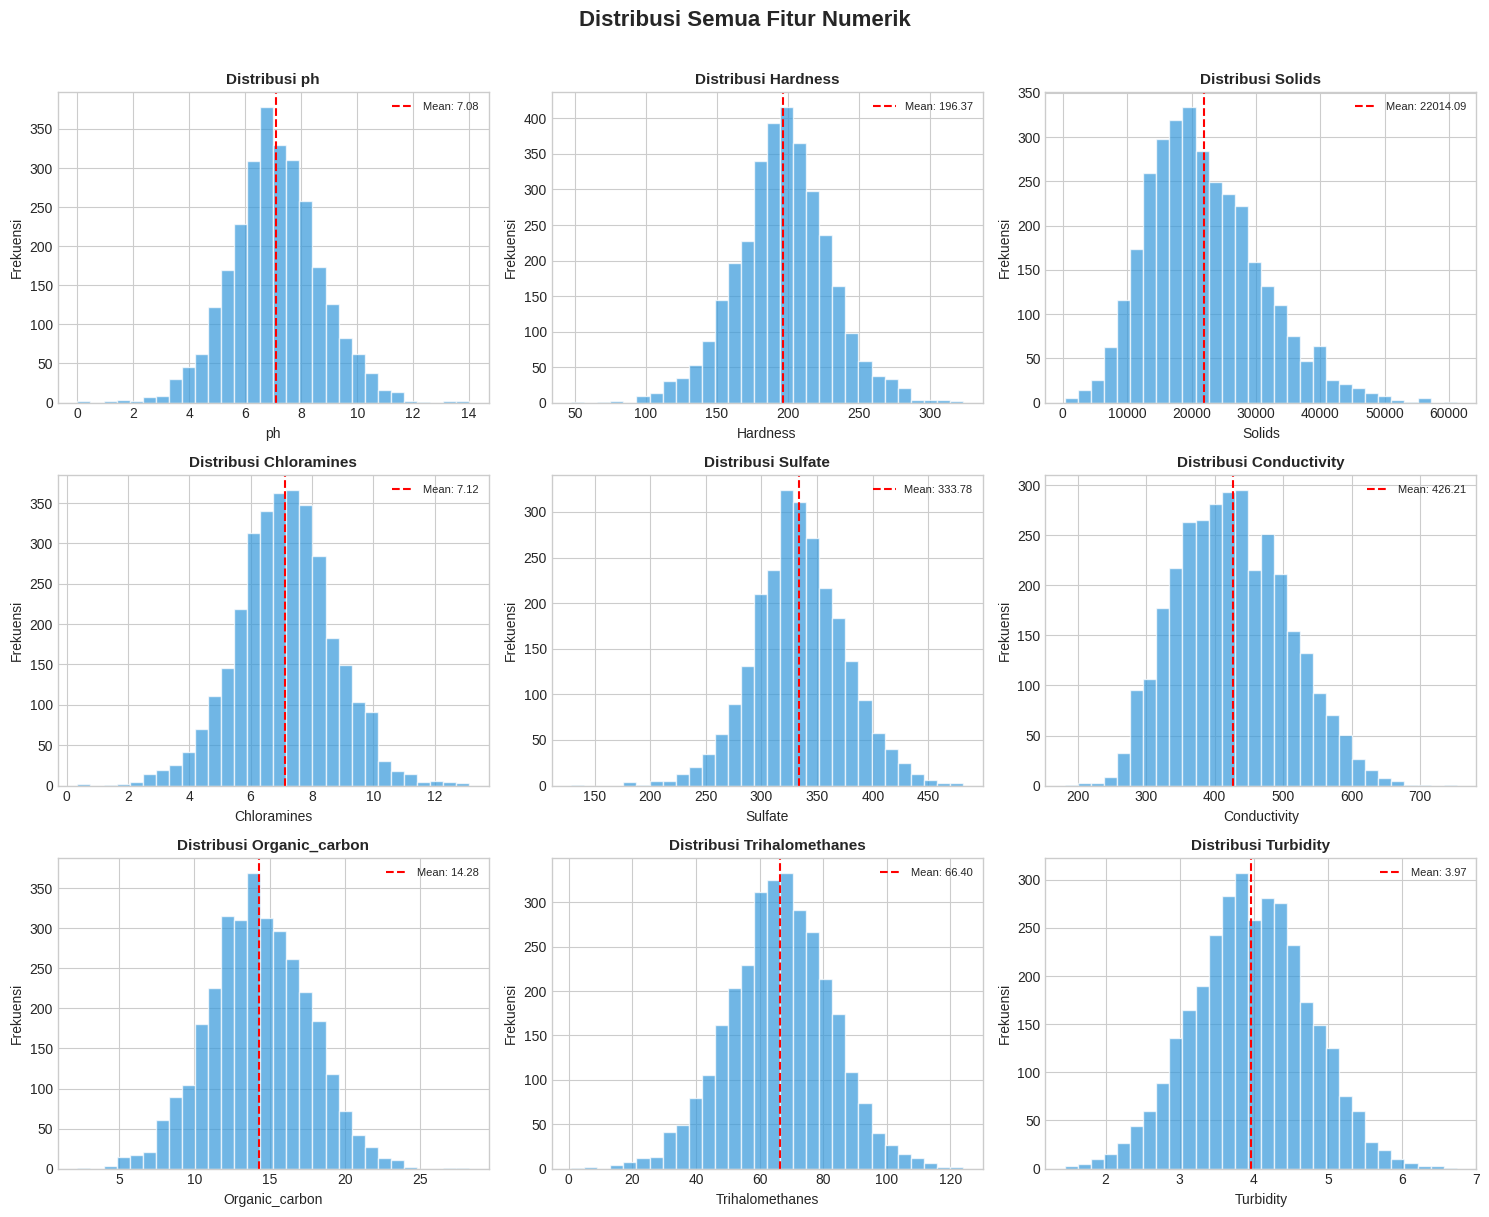

In [9]:
# 4.3 Distribusi Fitur Numerik
features = [col for col in df.columns if col != 'Potability']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Distribusi {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekuensi')

    # Tambahkan garis mean
    mean_val = df[feature].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Semua Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

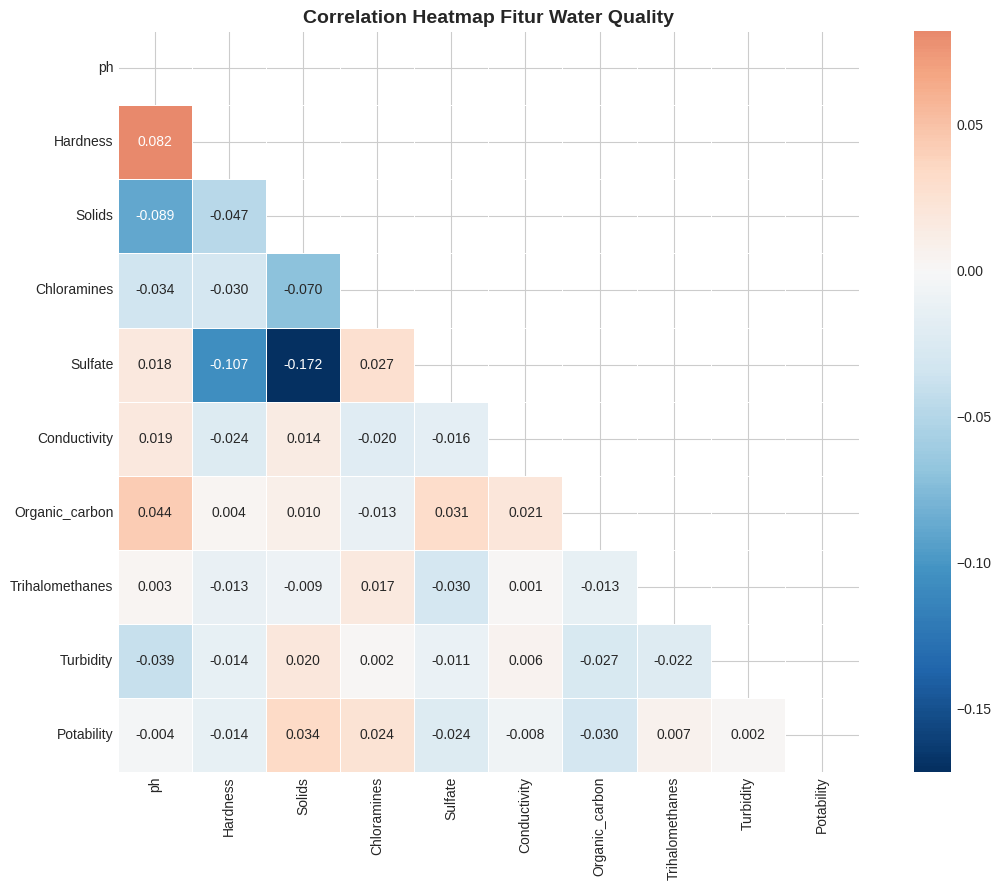

=== KORELASI DENGAN TARGET (Potability) ===
Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [10]:
# 4.4 Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            mask=mask,
            ax=ax,
            linewidths=0.5,
            square=True)
ax.set_title('Correlation Heatmap Fitur Water Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi dengan target
print('=== KORELASI DENGAN TARGET (Potability) ===')
print(df.corr()['Potability'].sort_values(ascending=False))

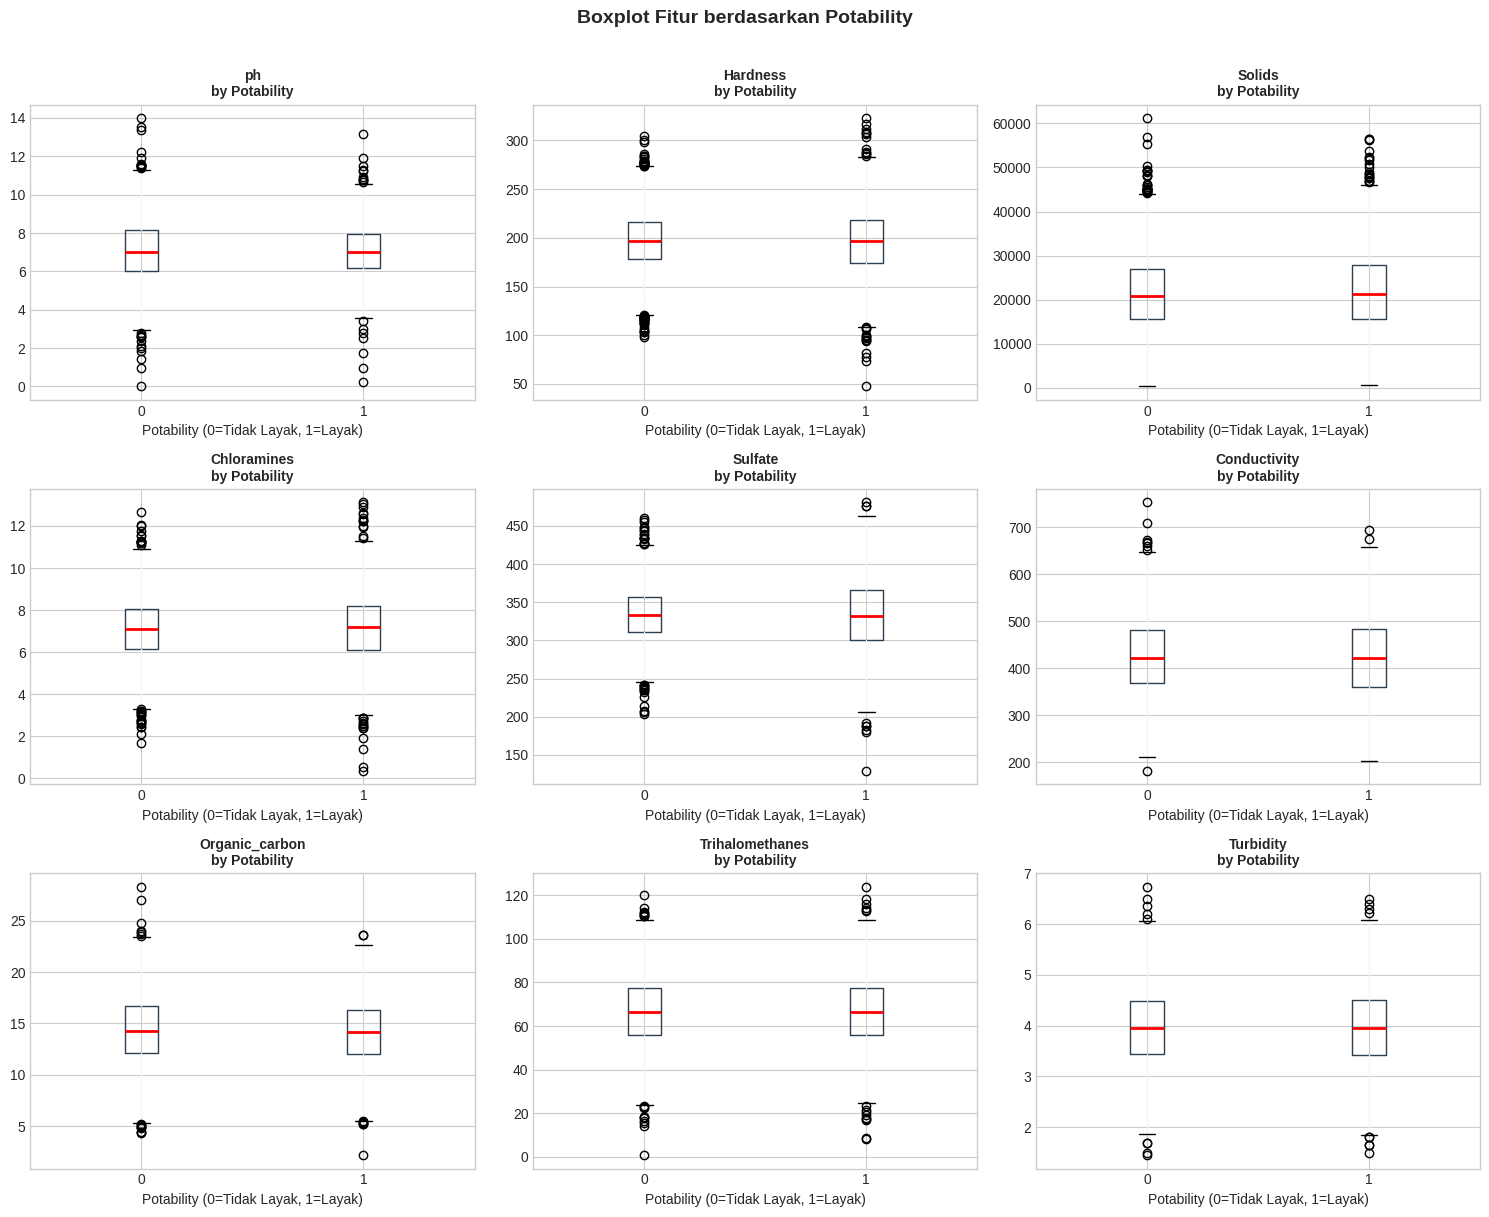

In [11]:
# 4.5 Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, by='Potability', ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{feature}\nby Potability', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Potability (0=Tidak Layak, 1=Layak)')

plt.suptitle('Boxplot Fitur berdasarkan Potability', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplot_by_potability.png', dpi=150, bbox_inches='tight')
plt.show()

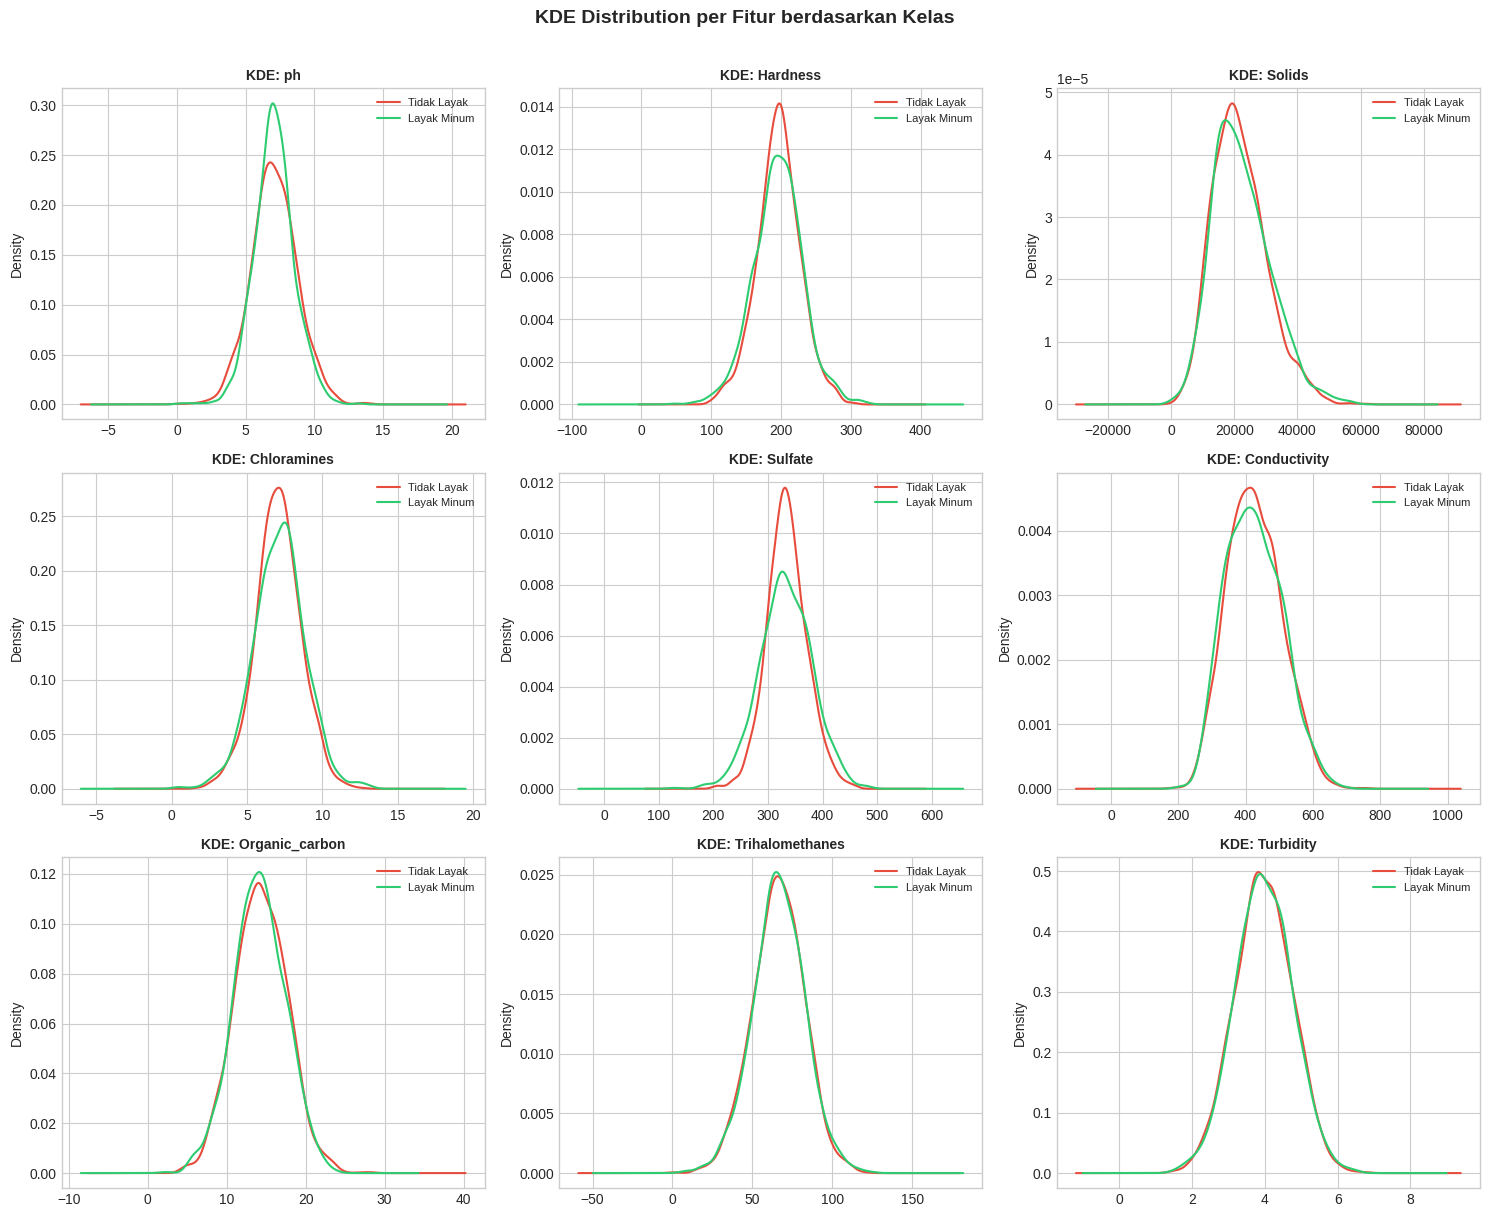

In [12]:
# 4.6 KDE Plot - Distribusi Fitur per Kelas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    df[df['Potability']==0][feature].dropna().plot.kde(ax=axes[i], label='Tidak Layak', color='#e74c3c')
    df[df['Potability']==1][feature].dropna().plot.kde(ax=axes[i], label='Layak Minum', color='#2ecc71')
    axes[i].set_title(f'KDE: {feature}', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('KDE Distribution per Fitur berdasarkan Kelas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_kde_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

Melakukan preprocessing data untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

In [13]:
# 5.1 Menangani Missing Values dengan Median Imputation
print('=== SEBELUM IMPUTASI ===')
print(df.isnull().sum())

# Impute dengan median (robust terhadap outlier)
imputer = SimpleImputer(strategy='median')
feature_cols = [col for col in df.columns if col != 'Potability']

df_processed = df.copy()
df_processed[feature_cols] = imputer.fit_transform(df_processed[feature_cols])

print('\n=== SETELAH IMPUTASI ===')
print(df_processed.isnull().sum())
print('\nSemua missing values berhasil ditangani!')

=== SEBELUM IMPUTASI ===
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

=== SETELAH IMPUTASI ===
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Semua missing values berhasil ditangani!


In [16]:
# 5.2 Cek dan Hapus Data Duplikat
n_duplicates = df_processed.duplicated().sum()
print(f'Jumlah baris duplikat: {n_duplicates}')

if n_duplicates > 0:
    df_processed = df_processed.drop_duplicates()
    print(f'Duplikat dihapus. Jumlah baris sekarang: {len(df_processed)}')
else:
    print('Tidak ada data duplikat.')

Jumlah baris duplikat: 0
Tidak ada data duplikat.


In [14]:
# 5.3 Mendeteksi dan Menangani Outlier dengan IQR Method
def remove_outliers_iqr(df, columns, multiplier=1.5):
    df_clean = df.copy()
    outlier_info = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        outlier_info[col] = {'lower': lower, 'upper': upper, 'n_outliers': n_outliers}

        # Clip outliers ke batas IQR
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    return df_clean, outlier_info

df_processed, outlier_info = remove_outliers_iqr(df_processed, feature_cols)

print('=== INFORMASI OUTLIER ===')
for col, info in outlier_info.items():
    print(f'{col}: {info["n_outliers"]} outlier(s) di-clip ke [{info["lower"]:.3f}, {info["upper"]:.3f}]')

=== INFORMASI OUTLIER ===
ph: 142 outlier(s) di-clip ke [3.889, 10.259]
Hardness: 83 outlier(s) di-clip ke [117.125, 276.393]
Solids: 47 outlier(s) di-clip ke [-1832.417, 44831.870]
Chloramines: 61 outlier(s) di-clip ke [3.146, 11.096]
Sulfate: 264 outlier(s) di-clip ke [267.158, 400.322]
Conductivity: 11 outlier(s) di-clip ke [191.648, 655.879]
Organic_carbon: 25 outlier(s) di-clip ke [5.328, 23.295]
Trihalomethanes: 54 outlier(s) di-clip ke [26.619, 106.695]
Turbidity: 19 outlier(s) di-clip ke [1.849, 6.091]


In [15]:
# 5.4 Normalisasi / Standardisasi Fitur
print('=== STATISTIK SEBELUM STANDARDISASI ===')
print(df_processed[feature_cols].describe().round(3))

scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print('\n=== STATISTIK SETELAH STANDARDISASI ===')
print(df_processed[feature_cols].describe().round(3))

=== STATISTIK SEBELUM STANDARDISASI ===
             ph  Hardness     Solids  Chloramines   Sulfate  Conductivity  \
count  3276.000  3276.000   3276.000     3276.000  3276.000      3276.000   
mean      7.073   196.392  21957.112        7.122   333.621       426.130   
std       1.382    32.017   8592.820        1.544    31.769        80.564   
min       3.889   117.125    320.943        3.146   267.158       191.648   
25%       6.278   176.851  15666.690        6.127   317.095       365.734   
50%       7.037   196.968  20927.834        7.130   333.074       421.885   
75%       7.870   216.667  27332.762        8.115   350.386       481.792   
max      10.259   276.393  44831.870       11.096   400.322       655.879   

       Organic_carbon  Trihalomethanes  Turbidity  
count        3276.000         3276.000   3276.000  
mean           14.283           66.432      3.967  
std             3.288           15.487      0.776  
min             5.328           26.619      1.849  
25%   

In [17]:
# 5.5 Train-Test Split & Simpan Dataset
X = df_processed.drop('Potability', axis=1)
y = df_processed['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== HASIL SPLIT DATA ===')
print(f'Training set: {X_train.shape[0]} sampel ({len(X_train)/len(X)*100:.1f}%)')
print(f'Testing set : {X_test.shape[0]} sampel ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nDistribusi kelas Training: {y_train.value_counts().to_dict()}')
print(f'Distribusi kelas Testing : {y_test.value_counts().to_dict()}')

# Gabungkan kembali X dan y untuk disimpan
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('water_potability_train.csv', index=False)
test_df.to_csv('water_potability_test.csv', index=False)
df_processed.to_csv('water_potability_preprocessing.csv', index=False)

print('\nDataset berhasil disimpan:')
print('  - water_potability_train.csv')
print('  - water_potability_test.csv')
print('  - water_potability_preprocessing.csv')

=== HASIL SPLIT DATA ===
Training set: 2620 sampel (80.0%)
Testing set : 656 sampel (20.0%)

Distribusi kelas Training: {0: 1598, 1: 1022}
Distribusi kelas Testing : {0: 400, 1: 256}

Dataset berhasil disimpan:
  - water_potability_train.csv
  - water_potability_test.csv
  - water_potability_preprocessing.csv


In [18]:
# 5.6 Ringkasan Preprocessing
print("=" * 50)
print("     RINGKASAN PREPROCESSING WATER QUALITY")
print("=" * 50)
print(f"Dataset awal         : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Dataset setelah proses: {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")
print()
print("Tahapan yang dilakukan:")
print("  1. Median Imputation untuk missing values")
print("  2. Penghapusan data duplikat")
print("  3. IQR-based Outlier Clipping")
print("  4. StandardScaler untuk normalisasi fitur")
print("  5. Stratified Train-Test Split (80/20)")
print("=" * 50)


     RINGKASAN PREPROCESSING WATER QUALITY
Dataset awal         : 3276 baris x 10 kolom
Dataset setelah proses: 3276 baris x 10 kolom

Tahapan yang dilakukan:
  1. Median Imputation untuk missing values (ph, Sulfate, Trihalomethanes)
  2. IQR-based Outlier Clipping untuk semua fitur numerik
  3. StandardScaler untuk normalisasi fitur
  4. Pengecekan dan penghapusan data duplikat
  5. Stratified Train-Test Split (80/20)
